In [1]:
from google.colab import files

uploaded = files.upload()

Saving FinalMergedDataset.csv to FinalMergedDataset.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("FinalMergedDataset.csv")

print("Dataset Loaded")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset Loaded
Rows: 1048
Columns: 54


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,GP,F,15,U,GT3,T,4,2,health,services,...,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,GP,F,16,U,GT3,T,3,3,other,other,...,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
    .str.replace("-","_")
)


print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'pstatus', 'medu', 'fedu', 'mjob', 'fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'dalc', 'walc', 'health', 'absences', 'g1', 'g2', 'g3', 'student_id', 'hours_studied', 'attendance', 'parental_involvement', 'access_to_resources', 'extracurricular_activities', 'sleep_hours', 'previous_scores', 'motivation_level', 'internet_access', 'tutoring_sessions', 'family_income', 'teacher_quality', 'school_type', 'peer_influence', 'physical_activity', 'learning_disabilities', 'parental_education_level', 'distance_from_home', 'gender', 'exam_score']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 54 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   school                      1048 non-null   object
 1   sex                         1048 non-null   object
 2   age                         1048 non-null   int64 
 3   address                     1048 non-null   object
 4   famsize                     1048 non-null   object
 5   pstatus                     1048 non-null   object
 6   medu                        1048 non-null   int64 
 7   fedu                        1048 non-null   int64 
 8   mjob                        1048 non-null   object
 9   fjob                        1048 non-null   object
 10  reason                      1048 non-null   object
 11  guardian                    1048 non-null   object
 12  traveltime                  1048 non-null   int64 
 13  studytime                   1048 non-null   int6

In [6]:
duplicate_count = df.duplicated().sum()

print(
    "Duplicates Before:",
    duplicate_count
)


df = df.drop_duplicates()


print(
    "Duplicates After:",
    df.duplicated().sum()
)

Duplicates Before: 0
Duplicates After: 0


In [7]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns


for col in numeric_columns:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [8]:
categorical_columns = df.select_dtypes(
    include="object"
).columns


for col in categorical_columns:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [9]:
for col in categorical_columns:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
    )

In [10]:
print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

Total Missing Values: 0


In [11]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns


for col in numeric_columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1


    lower = Q1 - 1.5*IQR

    upper = Q3 + 1.5*IQR


    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )


    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

In [12]:
if "previous_scores" in df.columns:

    df["previous_performance_level"] = pd.cut(
        df["previous_scores"],
        bins=[
            0,
            50,
            70,
            100
        ],
        labels=[
            "Low",
            "Medium",
            "High"
        ]
    )

In [13]:
if "previous_scores" in df.columns:

    df["previous_performance_level"] = pd.cut(
        df["previous_scores"],
        bins=[
            0,
            50,
            70,
            100
        ],
        labels=[
            "Low",
            "Medium",
            "High"
        ]
    )

In [14]:
if "hours_studied" in df.columns:

    df["study_level"] = pd.cut(
        df["hours_studied"],
        bins=[
            -1,
            10,
            20,
            100
        ],
        labels=[
            "Low",
            "Medium",
            "High"
        ]
    )

In [15]:
if "sleep_hours" in df.columns:

    df["sleep_quality"] = np.where(
        df["sleep_hours"] >= 7,
        "Good",
        "Poor"
    )

In [16]:
if all(x in df.columns for x in ["g1","g2","g3"]):

    df["internal_marks_average"] = (
        df["g1"]+
        df["g2"]+
        df["g3"]
    )/3

In [17]:
df["exam_score"].describe()

,exam_score
count,1048.000000
mean,67.100191
std,3.265764
min,59.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,75.000000


In [18]:
encoder = LabelEncoder()


categorical_columns = df.select_dtypes(
    include="object"
).columns


for col in categorical_columns:

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

In [19]:
categorical_columns = df.select_dtypes(
    include="category"
).columns


for col in categorical_columns:

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

In [20]:
print(df.shape)

df.head()

(1048, 58)


,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,physical_activity,learning_disabilities,parental_education_level,distance_from_home,gender,exam_score,previous_performance_level,study_level,sleep_quality,internal_marks_average
0,0,0,18.0,1,0,0,4.0,4.0,0,4,...,3.0,0,1,2,1,67.0,0,0,0,5.666667
1,0,0,17.0,1,0,1,1.0,1.0,0,2,...,4.0,0,0,1,0,61.0,2,2,0,5.333333
2,0,0,15.0,1,1,1,1.0,1.0,0,2,...,4.0,0,2,2,1,74.0,0,0,0,8.333333
3,0,0,15.0,1,0,1,4.0,2.0,1,3,...,4.0,0,1,1,1,71.0,0,0,0,14.666667
4,0,0,16.0,1,0,1,3.0,3.0,2,2,...,4.0,0,0,2,0,70.0,2,2,1,8.666667


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   school                      1048 non-null   int64  
 1   sex                         1048 non-null   int64  
 2   age                         1048 non-null   float64
 3   address                     1048 non-null   int64  
 4   famsize                     1048 non-null   int64  
 5   pstatus                     1048 non-null   int64  
 6   medu                        1048 non-null   float64
 7   fedu                        1048 non-null   float64
 8   mjob                        1048 non-null   int64  
 9   fjob                        1048 non-null   int64  
 10  reason                      1048 non-null   int64  
 11  guardian                    1048 non-null   int64  
 12  traveltime                  1048 non-null   float64
 13  studytime                   1048 

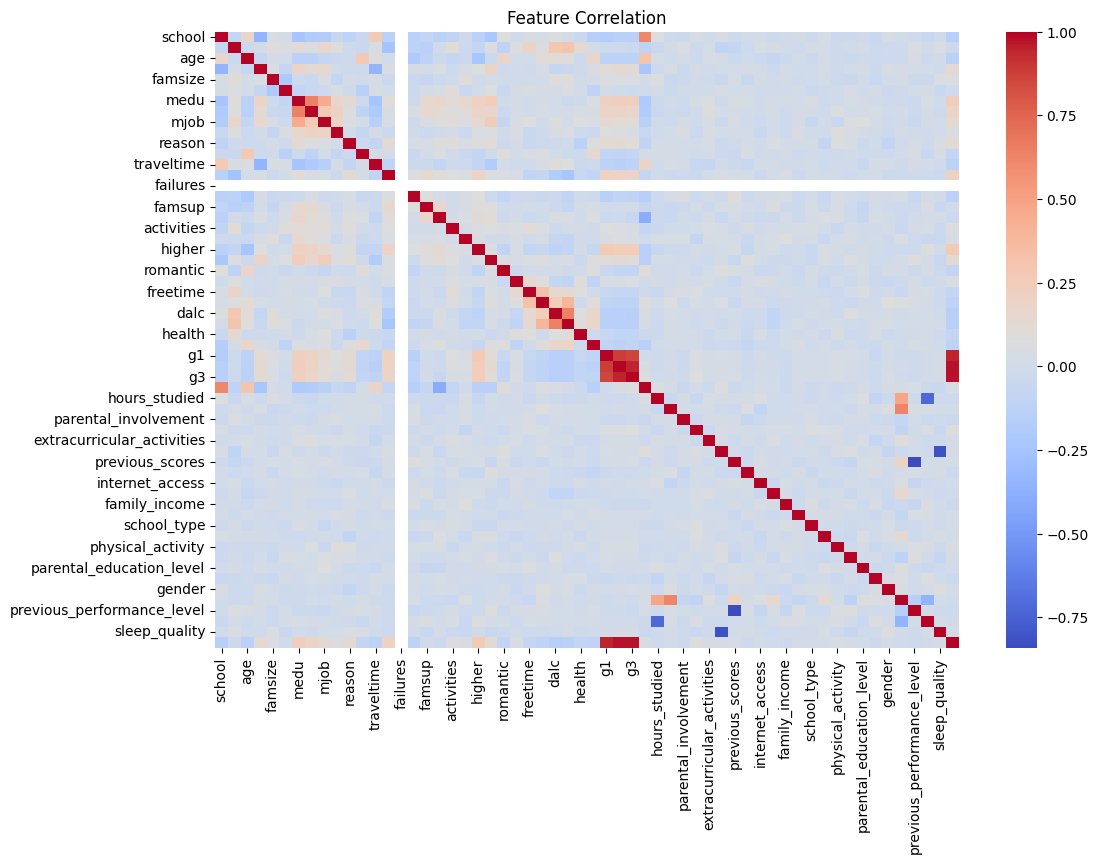

In [23]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation"
)

plt.show()

In [24]:
df.to_csv(
    "Cleaned_Student_Performance_Dataset.csv",
    index=False
)


print(
    "Clean Dataset Saved Successfully"
)

Clean Dataset Saved Successfully


In [25]:
from google.colab import files

files.download(
    "Cleaned_Student_Performance_Dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>